# Uncertainty Analysis: Monte Carlo vs Chance-Constrained Optimization

This notebook provides a comprehensive comparison between Monte Carlo and Chance-Constrained (CC) optimization approaches for the ammonia production case study.

## Analysis Components:
1. **CC-Pareto Optimization**: Solving the chance-constrained Pareto problem
2. **Monte Carlo Analysis**: Two uncertainty approaches (custom strategies vs fitted normal)
3. **Comparative Visualization**: Progressive comparison plots
4. **Choice Analysis**: Technology pathway analysis by risk ranges
5. **CC-Pareto Impact Distributions**: Confidence level analysis

All functions are modularized in `a1_uncertainty_mc_utils.py` and `a1_uncertainty_mc_unc_plots.py`.

In [1]:
# Configuration parameters
FORCE_RECALCULATION = False
N_MC_ITERATIONS = 1500
RANDOM_SEED = 666
SOLVER_NAME = "gurobi"
UNCERTAINTY_CUTOFF = 0.000001
N_TOP_PROCESSES = 19

# File paths
RESULTS_DIR = "data/results"
CC_PARETO_FILE = f"{RESULTS_DIR}/cc_pareto_results.pkl"
MC_STRATEGIES_FILE = f"{RESULTS_DIR}/mc_uncertainty_strategies.pkl"
MC_NORMAL_FILE = f"{RESULTS_DIR}/mc_fitted_normal.pkl"

print("✓ Configuration loaded successfully!")

✓ Configuration loaded successfully!


In [2]:
# Enable automatic reloading of modified modules
%load_ext autoreload
%autoreload 2

# Import required libraries
import os
import numpy as np
import pandas as pd

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Import our custom modules
import notebook_utils.a1_uncertainty_mc_utils as unc_utils
import notebook_utils.a1_uncertainty_mc_plots as unc_plots

# PULPO imports
from pulpo import pulpo
from pulpo.utils.uncertainty import processor
import pulpo.utils.uncertainty.monte_carlo as mc

print("✓ All libraries imported successfully!")
print("✓ Autoreload enabled - modules will update automatically when modified!")

✓ All libraries imported successfully!
✓ Autoreload enabled - modules will update automatically when modified!


### Import Libraries and Initialize Modules

Import necessary libraries and enable autoreload to automatically update custom modules when they are modified. This is useful during development and debugging.

## 1. PULPO Worker Initialization

Initialize the PULPO worker with the ammonia case study (assuming databases are already installed).

### Initialize PULPO Worker

The PULPO optimizer is initialized with:
- **Project**: ammonia_last - the ammonia production case study
- **Database**: ecoinvent 3.10 cutoff database + custom ammonia database
- **Method**: IPCC 2013 climate change impact assessment with uncertainty
- The intervention matrix links process activities to environmental flows

In [3]:
# Project configuration
PROJECT = "ammonia_last"
DATABASE = ["ecoinvent-3.10-cutoff", "ammonia"]
METHOD = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
DIRECTORY = "develop_tests"

# Initialize PULPO worker
pulpo_worker = pulpo.PulpoOptimizer(PROJECT, DATABASE, METHOD, DIRECTORY)
pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
pulpo_worker.get_lci_data()

print("\n✓ PULPO worker initialized!")
print(f"  Project: {PROJECT}")
print(f"  Database: {DATABASE}")
print(f"  Method: {METHOD}")


✓ PULPO worker initialized!
  Project: ammonia_last
  Database: ['ecoinvent-3.10-cutoff', 'ammonia']
  Method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')


### Define Problem Structure

The ammonia problem is defined with:
- **Choices**: Technology options for each process category (hydrogen production, methane sources, heat generation, etc.)
- **Demand**: Functional unit (1e7 kg ammonia per year)
- **Constraints**: Upper bounds on certain technologies to ensure realistic scenarios

In [4]:
# Define ammonia problem (choices, demand, upper bounds)
choices, demand = unc_utils.define_ammonia_problem(pulpo_worker)

# Instantiate the problem
pulpo_worker.instantiate(demand=demand, choices=choices)

print("\n✓ Ammonia problem defined and instantiated!")
print(f"  Choices: {len(choices)} technology categories")
print(f"  Demand: {list(demand.values())[0]:.2e} kg/yr ammonia")

Creating Instance
Instance created
Creating Instance
Instance created

✓ Ammonia problem defined and instantiated!
  Choices: 6 technology categories
  Demand: 1.71e+10 kg/yr ammonia


## 2. Chance-Constrained Pareto Optimization

In [7]:
# Run or load CC-Pareto optimization
if unc_utils.check_file_exists(CC_PARETO_FILE, FORCE_RECALCULATION):
    print(f"Loading existing CC-Pareto results from {CC_PARETO_FILE}...")
    cc_pareto_results = unc_utils.load_results(CC_PARETO_FILE)
else:
    print("Running CC-Pareto optimization...")
    
    # Get uncertainty strategies (base iteration)
    unc_strategies = unc_utils.get_uncertainty_strategies(METHOD)
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply all uncertainty strategies including expert knowledge refinements
    unc_utils.apply_all_expert_strategies(pulpo_worker, unc_strategies)
    
    # Create CC formulation
    normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(
        CC_env_cost=True, CC_var_bounds=['upper_limit']
    )
    
    # Solve CC-Pareto problem
    lambda_epsilon_array = np.arange(0.02, 1, 0.02)
    results_CC = pulpo_worker.solve_CC_problem(
        lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, 
        solver_name=SOLVER_NAME
    )
    
    # Package and save results
    cc_pareto_results = {
        'results_CC': results_CC,
        'lambda_epsilon_array': lambda_epsilon_array,
        'normal_metadata_env_cost': normal_metadata_env_cost,
        'normal_metadata_var_bounds': normal_metadata_var_bounds,
        'uncertainty_data': pulpo_worker.uncertainty_data
    }
    unc_utils.save_results(cc_pareto_results, CC_PARETO_FILE)

print(f"\n✓ CC-Pareto optimization completed! Generated {len(cc_pareto_results['results_CC'])} Pareto points")

Loading existing CC-Pareto results from data/results/cc_pareto_results.pkl...
✓ Results loaded from: data/results/cc_pareto_results.pkl

✓ CC-Pareto optimization completed! Generated 49 Pareto points


## 3. Monte Carlo Analysis (Two Approaches)

In [ ]:
# Monte Carlo Analysis 1: Custom Uncertainty Strategies
if unc_utils.check_file_exists(MC_STRATEGIES_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (strategies) from {MC_STRATEGIES_FILE}...")
    mc_strategies_results = unc_utils.load_results(MC_STRATEGIES_FILE)
else:
    print(f"Running Monte Carlo analysis with custom strategies ({N_MC_ITERATIONS} iterations)...")
    
    # Re-define problem for MC analysis
    choices, demand = unc_utils.define_ammonia_problem(pulpo_worker)
    
    # Get base uncertainty strategies
    unc_strategies = unc_utils.get_uncertainty_strategies(METHOD)
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply all uncertainty strategies including expert knowledge refinements
    unc_utils.apply_all_expert_strategies(pulpo_worker, unc_strategies)
    
    # Run Monte Carlo simulation
    mc_strategies_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    unc_utils.save_results(mc_strategies_results, MC_STRATEGIES_FILE)

print("\n✓ MC analysis with custom strategies completed!")
analysis_strategies = unc_utils.analyze_MC_results(mc_strategies_results, show_plot=True)

In [ ]:
# Monte Carlo Analysis 2: Fitted Normal Distributions
if unc_utils.check_file_exists(MC_NORMAL_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (normal) from {MC_NORMAL_FILE}...")
    mc_normal_results = unc_utils.load_results(MC_NORMAL_FILE)
else:
    print(f"Running Monte Carlo analysis with fitted normal distributions ({N_MC_ITERATIONS} iterations)...")
    
    # Re-define problem for MC analysis
    choices, demand = unc_utils.define_ammonia_problem(pulpo_worker)
    
    # Get base uncertainty strategies
    unc_strategies = unc_utils.get_uncertainty_strategies(METHOD)
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply all uncertainty strategies including expert knowledge refinements
    unc_utils.apply_all_expert_strategies(pulpo_worker, unc_strategies)
    
    # Transform distributions to normal
    pulpo_worker.uncertainty_data = processor.transform_to_normal(
        pulpo_worker.uncertainty_data, sample_size=100, plot_distribution=False
    )
    
    # Run Monte Carlo simulation
    mc_normal_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    unc_utils.save_results(mc_normal_results, MC_NORMAL_FILE)

print("\n✓ MC analysis with normal distributions completed!")
analysis_normal = unc_utils.analyze_MC_results(mc_normal_results, show_plot=True)

## 4. Comparative Analysis and Visualization

In [ ]:
# Create comparative summary table
comparison_df = unc_plots.create_summary_table(analysis_strategies, analysis_normal)

In [ ]:
# Generate progressive comparative plots
unc_plots.plot_comparative_mc_analysis(
    analysis_strategies, analysis_normal, 
    cc_pareto_results, RESULTS_DIR
)

## 5. Choice Analysis within Risk Ranges

In [ ]:
# Analyze technology choices across different risk ranges
print("=" * 80)
print("CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS")
print("=" * 80)

risk_ranges = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 0.95), (0.95, 1.0)]

risk_analysis_results = {
    f"{int(a*100)}%-{int(b*100)}%": res
    for (a, b) in risk_ranges
    if (res := unc_utils.analyze_choices_in_risk_range(
        mc_normal_results, analysis_normal, a, b, f"{int(a*100)}%-{int(b*100)}%"
    ))
}

print("\n" + "=" * 80)
print("CHOICE ANALYSIS COMPLETE")
print("=" * 80)

In [ ]:
# Visualize choice analysis
unc_plots.plot_choice_analysis(
    risk_analysis_results, mc_normal_results, 
    f"{RESULTS_DIR}/choice_analysis_by_risk.png"
)

## 6. CC-Pareto Impact Distribution Analysis

In [5]:
# Generate overlay samples and calculate CC-Pareto impact distributions
N_SAMPLES = 5000
CC_CONFIDENCE_LEVELS = [0.50, 0.80, 0.98]

print(f"Generating {N_SAMPLES} overlay samples...")

# Get uncertainty strategies
unc_strategies = unc_utils.get_uncertainty_strategies(METHOD)

# Import and filter uncertainty data
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
    plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
)

# Apply all uncertainty strategies including expert knowledge refinements
unc_utils.apply_all_expert_strategies(pulpo_worker, unc_strategies)

# Create CC formulation
pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

# Generate overlay samples
overlay_samples = mc.pre_sample_from_uncertainty(pulpo_worker, n_samples=N_SAMPLES, seed=RANDOM_SEED)


Generating 5000 overlay samples...
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.475472e+01
Characterized inventory: (2648, 23569) 21677
Filtered characterized inventory: (2648, 23569) 2771
Deviation from LCA score: 0.0008935495831803308
inventory (2648, 23569) filtering resulted in 2771 of 21677 exchanges (99.91% of total impact) and took 0.009 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 40 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 2477 
Parameters without uncertainty information: 237
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 57
Charactetization factors:
Parameters with uncertainty information: 18 
Parameters without uncertainty information: 22
Variable bounds:
Upper bound from choices without uncertainty information: 22
Upper bound from `up

Sampling uncertainty draws: 100%|██████████| 5000/5000 [17:16<00:00,  4.83it/s]


In [8]:
# Calculate impact distributions for each confidence level
print("\nCalculating impact distributions for CC-Pareto confidence levels:")
impact_distributions = {}

for lambda_val in CC_CONFIDENCE_LEVELS:
    if lambda_val in cc_pareto_results['results_CC']:
        s_vector = cc_pareto_results['results_CC'][lambda_val]['Scaling Vector'].sort_index()
        level_name = f"λ = {lambda_val}"
        impact_distributions[lambda_val] = unc_utils.calculate_impact_distribution(
            overlay_samples, s_vector, level_name
        )
    else:
        print(f"Warning: λ = {lambda_val} not found in CC-Pareto results")

print(f"\n✓ Impact distributions calculated for {len(impact_distributions)} confidence levels")


Calculating impact distributions for CC-Pareto confidence levels:
✓ λ = 0.5: Mean = -9.94e+09, Std = 9.32e+09
✓ λ = 0.8: Mean = -5.39e+09, Std = 7.46e+09
✓ λ = 0.98: Mean = 1.55e+10, Std = 6.06e+08

✓ Impact distributions calculated for 3 confidence levels


Plotting impact distributions for λ values: [0.5, 0.8, 0.98]


c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\notebook_utils\a1_uncertainty_mc_plots.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


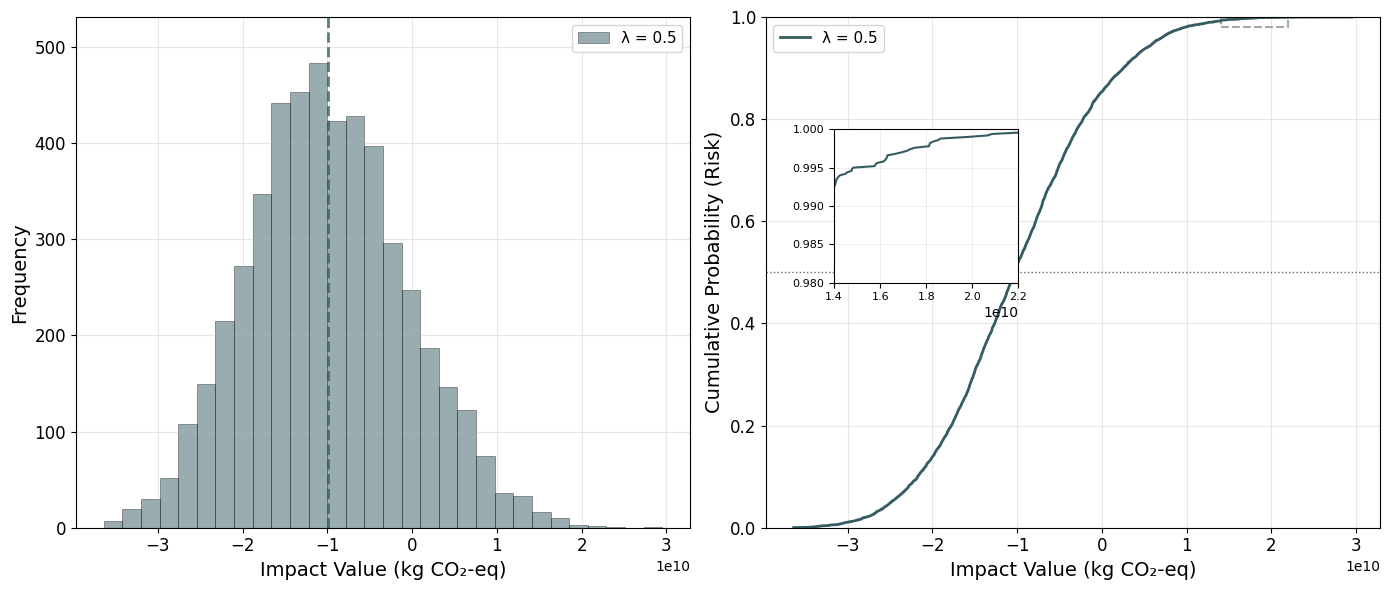

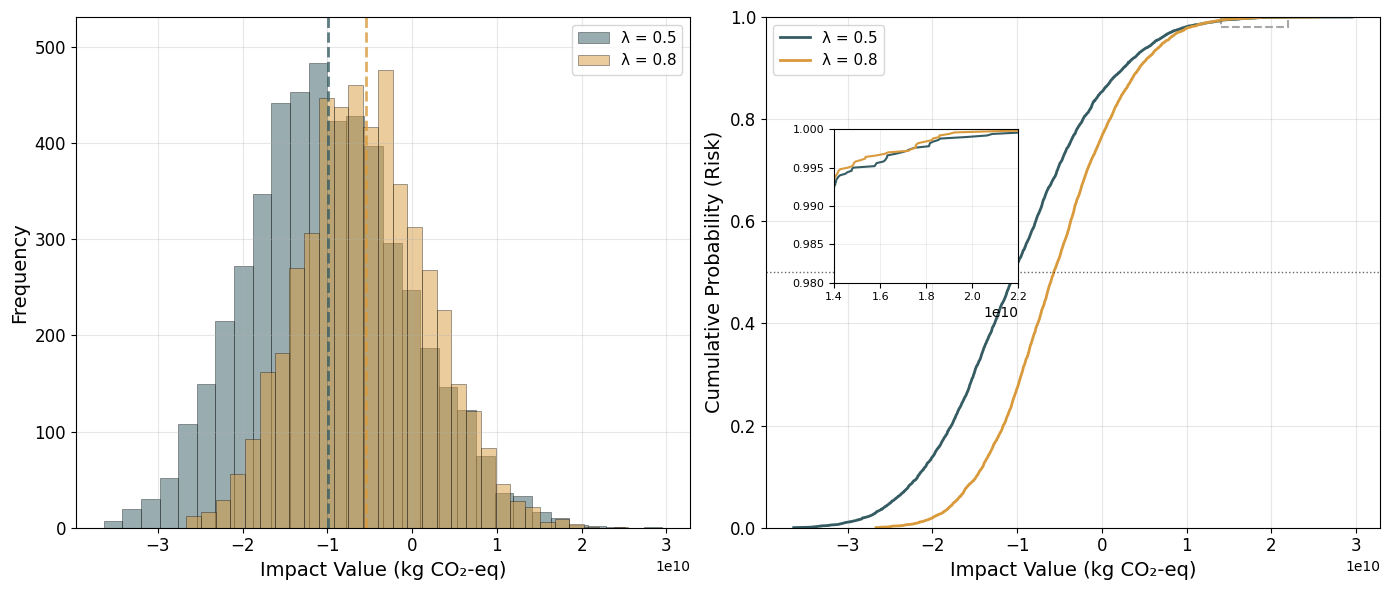

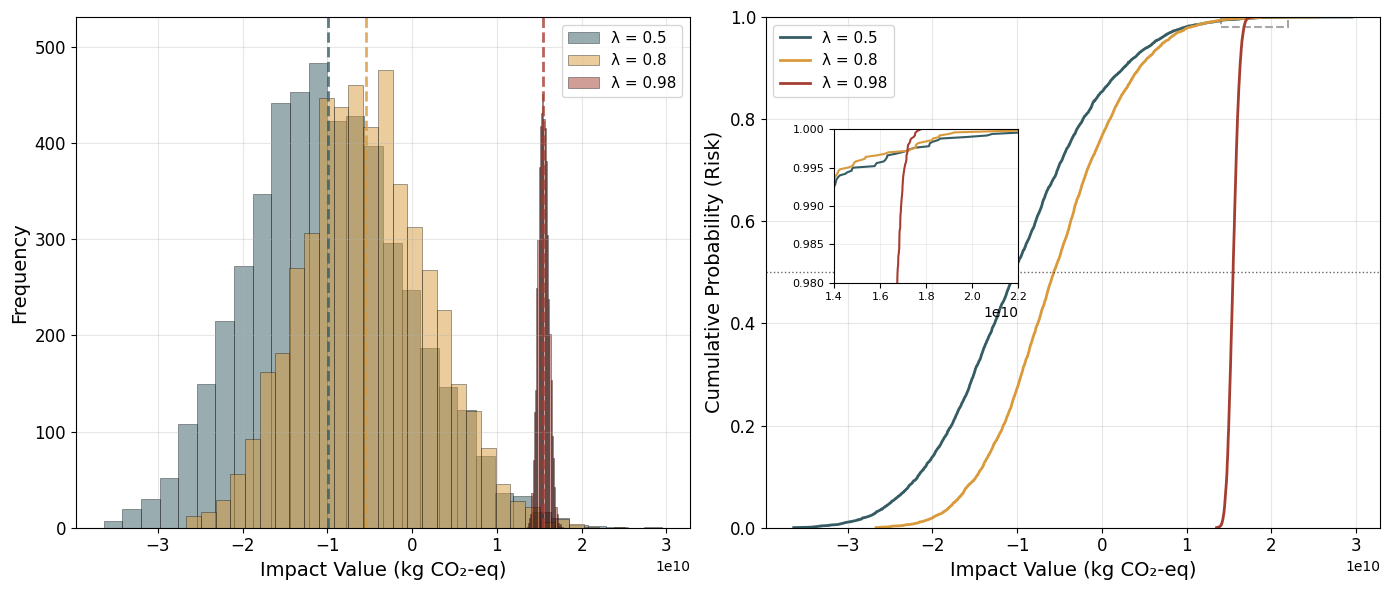


✓ Saved 3 incremental CC-Pareto distribution figures to data/results

CC-PARETO IMPACT DISTRIBUTION SUMMARY
 Confidence Level (λ) Mean Impact  Std Dev CV (%) Min Impact Max Impact 5th Percentile 95th Percentile
                 0.50   -9.94e+09 9.32e+09  -93.7  -3.64e+10   2.95e+10      -2.49e+10        6.15e+09
                 0.80   -5.39e+09 7.46e+09 -138.4  -2.66e+10   2.55e+10      -1.74e+10        7.35e+09
                 0.98    1.55e+10 6.06e+08    3.9   1.35e+10   1.78e+10       1.45e+10        1.65e+10

✓ CC-Pareto impact distribution analysis completed!
✓ Visualization saved to: data/results/cc_pareto_impact_distributions_step*.png


In [9]:
# Visualize CC-Pareto impact distributions
unc_plots.plot_cc_pareto_distributions(impact_distributions, RESULTS_DIR)

# Create summary statistics table
print("\n" + "="*80)
print("CC-PARETO IMPACT DISTRIBUTION SUMMARY")
print("="*80)

summary_data = []
for lambda_val, impacts in impact_distributions.items():
    summary_data.append({
        'Confidence Level (λ)': lambda_val,
        'Mean Impact': f"{np.mean(impacts):.2e}",
        'Std Dev': f"{np.std(impacts):.2e}",
        'CV (%)': f"{np.std(impacts)/np.mean(impacts)*100:.1f}",
        'Min Impact': f"{np.min(impacts):.2e}",
        'Max Impact': f"{np.max(impacts):.2e}",
        '5th Percentile': f"{np.percentile(impacts, 5):.2e}",
        '95th Percentile': f"{np.percentile(impacts, 95):.2e}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*80)

print(f"\n✓ CC-Pareto impact distribution analysis completed!")
print(f"✓ Visualization saved to: {RESULTS_DIR}/cc_pareto_impact_distributions_step*.png")